# Day 5 — The Capstone: Finding What No One Taught You to Find

The final challenge: **anomaly detection** — finding patterns no one explicitly taught the model to
recognise.

Every model this week learned from labels: "this is a 7", "this is a cat", "the next value is 0.83".
But the most valuable problems often have **no labels**. A water utility doesn't have a tidy dataset
of 10,000 labelled pipe leaks; a factory doesn't have examples of every possible machine failure.
What they have is mountains of *normal* data.

The trick:

> **Train a model to reconstruct normal data. It will be good at reconstructing normal, and bad at
> reconstructing anything else. The reconstruction error *is* the anomaly score.**

Today you will build the complete pipeline:

1. Understand **autoencoders** and see one work on MNIST
2. The capstone: monitor a **network of pressure sensors** in a water distribution system
3. Prepare real-world-style time series: **normalisation** and **windowing**
4. Build and train an **LSTM autoencoder** on normal operation only
5. Pick a **threshold**, detect a leak the model was never shown, and visualise the results
6. Confirm the find with **change point detection**
7. Package it as a **project you can actually show off**

---

## Autoencoders: Learning by Copying

An **autoencoder** is a network trained to output... its own input. That sounds useless until you add
the constraint that makes it interesting: a **bottleneck**.

<div style="text-align: center"><img src="autoencoder.png" width="600"/></div>

- The **encoder** compresses the input into a small *latent code*
- The **decoder** rebuilds the input from that code alone
- The loss is the **reconstruction error** (e.g. MSE/MAE between input and output)

<div style="text-align: center"><img src="AD_anomaly_detection.png" width="900"/></div>

To pull this off, the network can't memorise — it must learn the *essential structure* of the data:
the patterns, the regularities, the "rules of normal". And that's the key to anomaly detection:
inputs that *follow* the learned rules reconstruct well; inputs that *break* them don't.

Notice there are **no labels anywhere**. The data is its own teacher — this is *unsupervised*
(strictly, self-supervised) learning.

In [1]:
import torch
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

from torch import nn, optim
from torch.utils.data import Subset, DataLoader
import time

%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Using device: mps


## Warm-up: An Autoencoder on MNIST

Before the capstone, let's see the whole idea work on familiar ground. We squeeze each 784-pixel
digit through a **32-number bottleneck** (a 24× compression) and train the network to rebuild the
image from those 32 numbers alone.

In [ ]:
class DenseAutoEncoder(nn.Module):
    def __init__(self, bottleneck=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128), nn.ReLU(),
            nn.Linear(128, bottleneck), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 128), nn.ReLU(),
            nn.Linear(128, 784), nn.Sigmoid(),     # pixels live in [0, 1]
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


mnist_train = Subset(torchvision.datasets.MNIST(root='./data', train=True, download=True,
                                                transform=transforms.ToTensor()), range(12000)) #different way to load a subset of the dataset
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor())
mnist_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)

ae = DenseAutoEncoder().to(device)
optimizer = optim.Adam(ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(5):
    losses = []
    for images, _ in mnist_loader:               # note: the labels are NEVER used!
        x = images.view(images.size(0), -1).to(device)
        loss = criterion(ae(x), x)               # target = the input itself
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
    print(f'Epoch {epoch+1} | reconstruction loss: {np.mean(losses):.4f}')

Epoch 1 | reconstruction loss: 0.0930
Epoch 2 | reconstruction loss: 0.0563
Epoch 3 | reconstruction loss: 0.0405
Epoch 4 | reconstruction loss: 0.0344
Epoch 5 | reconstruction loss: 0.0296


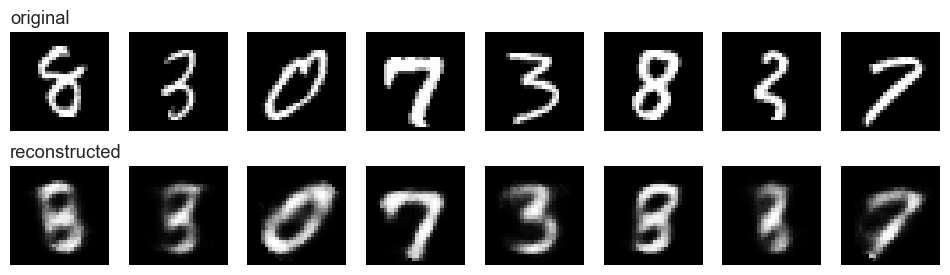

In [3]:
# Top row: originals. Bottom row: rebuilt from just 32 numbers.
ae.eval()
images, _ = next(iter(DataLoader(mnist_test, batch_size=8, shuffle=True)))
with torch.no_grad():
    recon = ae(images.view(8, -1).to(device)).cpu().view(8, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i in range(8):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[1, i].imshow(recon[i], cmap='gray')
    axes[0, i].axis('off'); axes[1, i].axis('off')
axes[0, 0].set_title('original', loc='left'); axes[1, 0].set_title('reconstructed', loc='left')
plt.show()

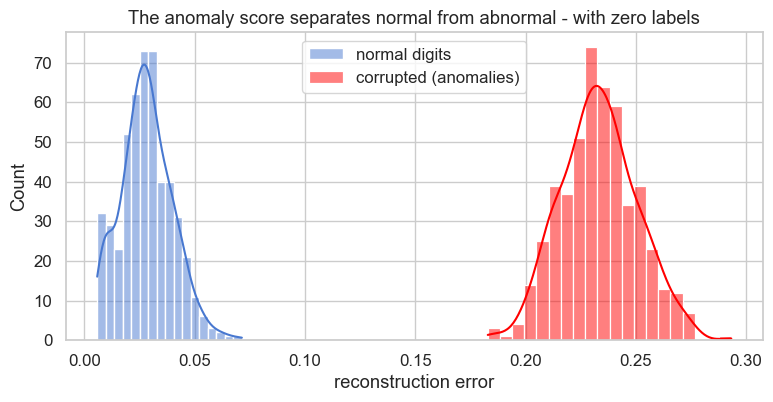

In [4]:
# Now the anomaly detection punchline: feed it something that ISN'T a normal digit.
# Reconstruction error on clean digits vs digits corrupted with heavy noise:
test_imgs = torch.stack([mnist_test[i][0] for i in range(500)]).view(500, -1).to(device)
corrupted = (test_imgs + 0.8 * torch.randn_like(test_imgs)).clamp(0, 1)

with torch.no_grad():
    err_clean = ((ae(test_imgs) - test_imgs) ** 2).mean(dim=1).cpu()
    err_anom  = ((ae(corrupted) - corrupted) ** 2).mean(dim=1).cpu()

plt.figure(figsize=(9, 4))
sns.histplot(err_clean, label='normal digits', kde=True)
sns.histplot(err_anom, label='corrupted (anomalies)', kde=True, color='red')
plt.xlabel('reconstruction error'); plt.legend()
plt.title('The anomaly score separates normal from abnormal - with zero labels')
plt.show()

Two cleanly separated distributions: draw a threshold between them and you have an anomaly detector.
That's the entire principle. Now let's do it on a problem with real-world structure — and a time
dimension.

---

# The Capstone: Leak Detection in a Water Network

**The scenario.** You're monitoring a water distribution network instrumented with pressure sensors
reporting every 30 minutes. Pressures follow strong **daily cycles** (morning showers, evening dishes)
plus noise. One day, somewhere in the network, a pipe starts leaking: pressure near the leak begins to
sag — subtly at first, then more. Nobody tells you when, where, or whether it happened. **Your model
must figure that out from the data alone.**

The plan, end to end:

1. **Data**: a clean "normal operation" recording (training) and a recording that may contain a leak (test)
2. **Normalise** with a *static z-score* — the six sensors sit at different baselines and scales
3. **Window** the multivariate series into fixed-length sequences (Day 4 skills!)
4. **Model**: an LSTM autoencoder — the encoder–decoder from Day 4's taxonomy, trained Day 2-style
5. **Threshold**: calibrate "how wrong is too wrong" on a validation set
6. **Detect & visualise**: score the test period, flag anomalies, confirm with change point detection

> **Note on the data.** This pipeline was originally built for the *Hanoi water network* benchmark —
> the original notebook is included as `extras/LSTM_AE_Hanoi_reference.ipynb` (its `Scenario-*.csv`
> data files are distributed separately). To make today's notebook fully self-contained, we
> **simulate** the same kind of data below. Bonus: since *we* control the simulated leak, we can
> grade our detector honestly at the end. To show off afterwards, re-run this pipeline on a real
> dataset — see the project brief at the bottom.

## Step 1: The Data

In [5]:
# Simulate a small sensor network: daily + weekly cycles, sensor-specific baselines, noise.
# The test scenario includes a leak: a slowly growing pressure drop on the sensors near it.
READINGS_PER_DAY = 48        # every 30 minutes

def make_scenario(n_days, start, leak_start_day=None, leak_sensors=(3, 4), leak_depth=5.0,
                  n_sensors=6, seed=0):
    rng = np.random.default_rng(seed)
    n = n_days * READINGS_PER_DAY
    step = np.arange(n)
    index = pd.date_range(start, periods=n, freq='30min')
    df = pd.DataFrame(index=index)
    df.index.name = 'Timestamp'

    for s in range(1, n_sensors + 1):
        baseline = 45 + 4 * s                                            # each sensor has its own level
        daily  = 3.5 * np.sin(2 * np.pi * step / READINGS_PER_DAY + 0.4 * s)  # demand cycle
        weekly = 1.2 * np.sin(2 * np.pi * step / (READINGS_PER_DAY * 7))      # weekend effect
        noise  = rng.normal(0, 0.35, n)
        pressure = baseline + daily + weekly + noise

        if leak_start_day is not None and s in leak_sensors:
            leak_at = leak_start_day * READINGS_PER_DAY
            growth = np.linspace(0, leak_depth, n - leak_at) ** 1.5      # slow at first, then worse
            pressure[leak_at:] -= growth

        df[f'Sensor_{s}'] = pressure
    return df

# Training data: 4 weeks of purely NORMAL operation (this is all the model ever learns from)
train_df = make_scenario(n_days=28, start='2025-01-01', seed=1)

# Test data: 2 weeks during which a leak starts on day 7, near sensors 3 and 4
LEAK_START_DAY = 7
test_df = make_scenario(n_days=14, start='2025-02-01', leak_start_day=LEAK_START_DAY, seed=2)
leak_time = test_df.index[LEAK_START_DAY * READINGS_PER_DAY]

print('train:', train_df.shape, '  test:', test_df.shape)
train_df.head()

train: (1344, 6)   test: (672, 6)


,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6
Timestamp,,,,,,
2025-01-01 00:00:00,50.483919,55.462745,60.410968,64.266776,68.279446,71.348654
2025-01-01 00:30:00,51.082088,56.087567,60.460202,64.066821,68.171580,71.225402
2025-01-01 01:00:00,51.311403,55.575120,60.737064,64.373171,68.177770,70.589792
2025-01-01 01:30:00,51.104056,56.669870,60.085573,64.028481,67.395895,70.134982
2025-01-01 02:00:00,52.198769,56.322449,60.536246,64.475971,67.414445,69.675884


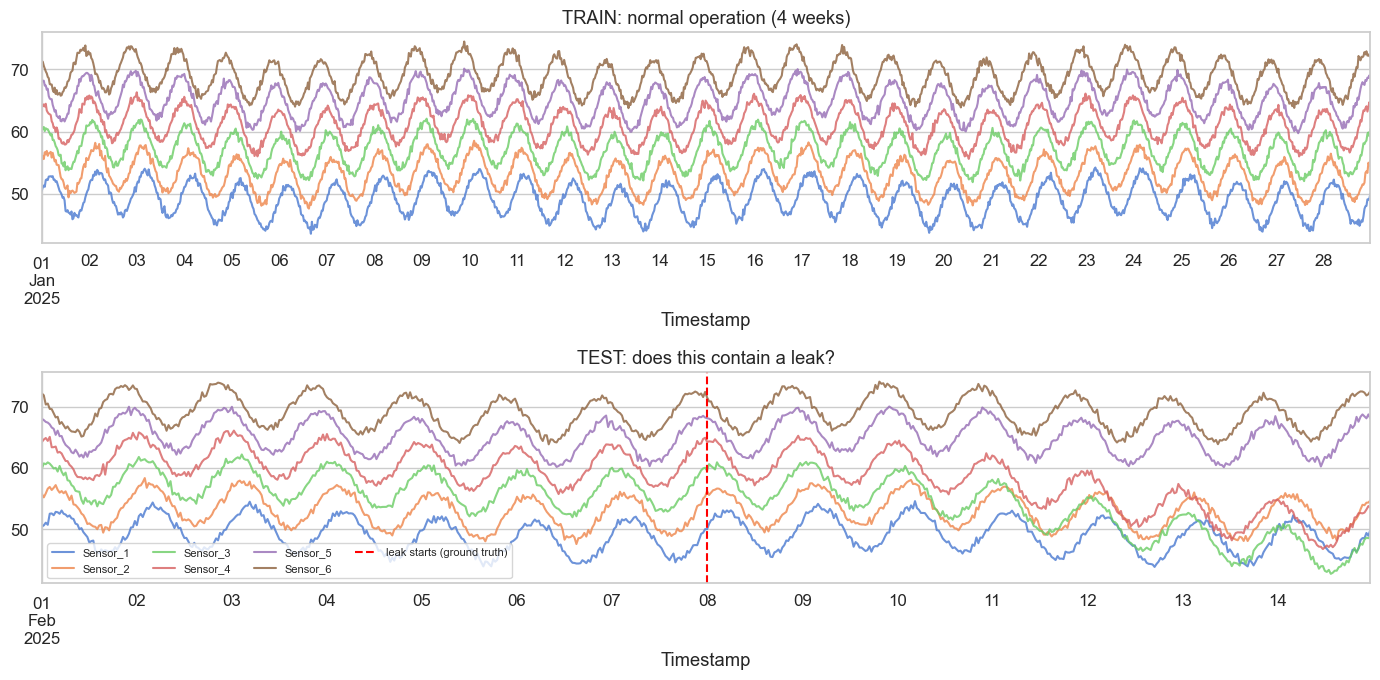

In [6]:
# Look at the data. Can YOU spot the leak by eye?
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
train_df.plot(ax=axes[0], legend=False, alpha=0.8)
axes[0].set_title('TRAIN: normal operation (4 weeks)')
test_df.plot(ax=axes[1], legend=True, alpha=0.8)
axes[1].axvline(leak_time, color='red', linestyle='--', label='leak starts (ground truth)')
axes[1].legend(loc='lower left', ncol=4, fontsize=8)
axes[1].set_title('TEST: does this contain a leak?')
plt.tight_layout()
plt.show()

The drop is buried inside daily cycles, weekly drift, noise, and six different sensor baselines — by
the time it's obvious to the eye, thousands of litres are gone. Early detection is exactly what the
autoencoder is for.

## Step 2: Normalise — A Static Z-Score

Day 2's lesson: normalise your inputs. Here it's doubly important — our six sensors sit at different
baselines (≈49 to ≈69), and without rescaling the reconstruction loss would be dominated by whichever
sensors carry the largest raw numbers. So we standardise each sensor with a **z-score**: subtract its
mean and divide by its standard deviation, putting them all on a common ~0-mean, unit-spread scale.
We compute that mean and std **once, from the training data only**, and apply the same fixed scaling
to the test set (never peek at the future).

**Why a *static* z-score and not a *moving* one?** A moving (rolling-window) z-score re-standardises
each reading against its *recent* neighbours. That's the right tool when the data has a slow,
legitimate **trend or season** you want to remove — e.g. a *year* of readings where summer demand
drifts steadily upward — because the rolling baseline follows the season but not a sudden fault. But
our record is short and has no such trend, and a rolling window has a nasty side-effect for *our*
problem: because our leak grows **slowly**, the trailing mean would gradually creep down to follow it,
quietly *erasing the very deviation we're trying to catch.* For a short, trend-free signal like this,
a single fixed scaling exposes the leak far more clearly. (Match the tool to the data!)

In [7]:
# static z-score: one mean & std PER SENSOR, computed from the training data only...
train_mean, train_std = train_df.mean(), train_df.std()

# ...then applied as a fixed scaling to BOTH sets (the test set never influences the scaling).
train_norm = (train_df - train_mean) / train_std
test_norm  = (test_df  - train_mean) / train_std

train_norm.describe().round(2)

,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,Sensor_6
count,1344.00,1344.00,1344.00,1344.00,1344.00,1344.00
mean,0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.05,-2.06,-1.94,-2.05,-2.00,-1.98
25%,-0.86,-0.89,-0.86,-0.87,-0.85,-0.84
50%,-0.00,0.01,0.02,-0.01,-0.00,0.01
75%,0.87,0.86,0.89,0.86,0.88,0.85
max,1.97,2.10,1.92,2.03,1.94,2.09


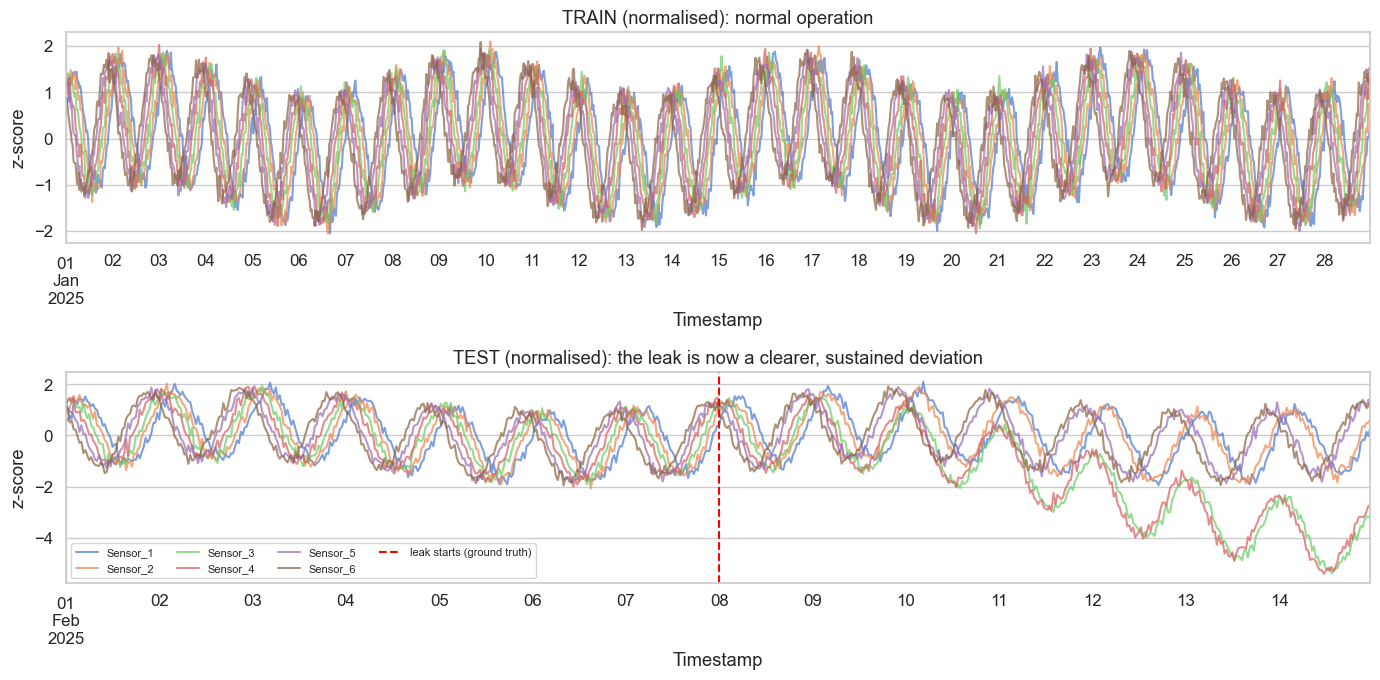

In [8]:
# The same data after the static z-score. Every sensor now sits on a common scale (~0 mean, unit
# spread), so the network can compare them fairly — yet the leak still stands out as a sustained
# deviation in the affected sensors. Compare this with the raw plot above.
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
train_norm.plot(ax=axes[0], legend=False, alpha=0.7)
axes[0].set_title('TRAIN (normalised): normal operation'); axes[0].set_ylabel('z-score')
test_norm.plot(ax=axes[1], legend=True, alpha=0.7)
axes[1].axvline(leak_time, color='red', linestyle='--', label='leak starts (ground truth)')
axes[1].legend(loc='lower left', ncol=4, fontsize=8)
axes[1].set_title('TEST (normalised): the leak is now a clearer, sustained deviation')
axes[1].set_ylabel('z-score')
plt.tight_layout()
plt.show()

## Step 3: Window Into Sequences

Just like Day 4: slide a window along the series. Each sample is one day of readings across all
sensors — shape `(48, 6)` = `(seq_len, n_features)`. The autoencoder will learn to reconstruct
entire days of normal network behaviour.

We also split off a **validation set** from the *normal* data to calibrate the detection threshold
(Day 2: never calibrate on training data). For a time series there's a subtlety, though: our windows
slide one step at a time, so neighbouring windows overlap by ~98% — they're near-duplicates. A *random*
split would scatter those near-duplicates across train and validation, so the model would effectively
have *seen* its "unseen" validation data, making the threshold optimistically tight. The fix is to
split the series **in time first** — train on the earlier portion, validate on a later contiguous
block — and *then* window each part separately, so the validation windows share **no** time steps with
training.

In [9]:
def make_sequences(df, window):
    values = df.values.astype(np.float32)
    return np.array([values[i : i + window] for i in range(len(values) - window + 1)])

WINDOW = READINGS_PER_DAY            # one full day per sequence

# Split the normal series in TIME first (no shuffling), THEN window each part separately. This keeps
# the validation windows in a later, contiguous block that shares NO time steps with training -- so
# the heavily-overlapping sliding windows can't leak near-duplicates across the split.
split_at = int(0.85 * len(train_norm))
train_part = train_norm.iloc[:split_at]
val_part   = train_norm.iloc[split_at:]          # later, contiguous block of normal data

X_s_train  = make_sequences(train_part, WINDOW)
X_s_val    = make_sequences(val_part,   WINDOW)
X_seq_test = make_sequences(test_norm,  WINDOW)
print('train sequences:', X_s_train.shape, '  val sequences:', X_s_val.shape,
      '  test sequences:', X_seq_test.shape)

# convert to tensors (enables GPU processing)
x_s_train_tensor = torch.tensor(X_s_train)
x_s_val_tensor   = torch.tensor(X_s_val)
x_s_test_tensor  = torch.tensor(X_seq_test)
print('train:', x_s_train_tensor.shape, ' val:', x_s_val_tensor.shape, ' test:', x_s_test_tensor.shape)

train sequences: (1095, 48, 6)   val sequences: (155, 48, 6)   test sequences: (625, 48, 6)
train: torch.Size([1095, 48, 6])  val: torch.Size([155, 48, 6])  test: torch.Size([625, 48, 6])


## Step 4: The LSTM Autoencoder

Now we fuse the week together. The architecture below is the encoder–decoder from Day 4's taxonomy,
built from stacked LSTMs:

- **Encoder**: two LSTM layers that read a day of sensor data and squeeze it down to a small
  `embedding_dim` per time step — the bottleneck
- **Decoder**: two LSTM layers that expand the embedding back out
- a final **Linear** layer mapping back to the original number of sensors

We train with **L1 loss** (mean absolute error — Day 1's loss zoo!), which is robust to the noise
spikes in sensor data. *(This is the same `MVLSTMAutoEncoder` used in the original Hanoi study —
see the extras folder, including `conv_lstm_output_dimensions_test.ipynb` for a Conv+LSTM hybrid.)*

In [ ]:
class MVLSTMAutoEncoder(nn.Module):
    def __init__(self, seq_len, embedding_dim, feature_size):
        super(MVLSTMAutoEncoder, self).__init__()
        #input parameters
        self.seq_len = seq_len # window length
        self.feature_size = feature_size # number of columns/sensors
        self.hidden_1 = embedding_dim * 2 # starting hidden size
        self.hidden_2 = embedding_dim # ending hidden size (embedding dimension/bottleneck)

        self.encode1 = nn.LSTM(input_size=self.feature_size, hidden_size=self.hidden_1, num_layers=1, bidirectional=False, batch_first=True)
        self.encode2 = nn.LSTM(input_size=self.hidden_1, hidden_size=self.hidden_2, num_layers=1, bidirectional=False, batch_first=True)

        self.decode1 = nn.LSTM(input_size=self.hidden_2, hidden_size=self.hidden_2, num_layers=1, bidirectional=False, batch_first=True)
        self.decode2 = nn.LSTM(input_size=self.hidden_2, hidden_size=self.hidden_1, num_layers=1, bidirectional=False, batch_first=True)

        self.dense = nn.Linear(self.hidden_1, self.feature_size)

    def forward(self, x):
        x, _ = self.encode1(x)
        x, _ = self.encode2(x)
        x, _ = self.decode1(x)
        x, _ = self.decode2(x)
        x = self.dense(x)
        return x

In [ ]:
def train_model(training_dataset, val_dataset, n_epochs, embedding_dim, lr=1e-3):
    feature_size = training_dataset.shape[-1] # get number of columns/sensors
    window_size = training_dataset.shape[1] # get the window length
    model = MVLSTMAutoEncoder(seq_len=window_size, embedding_dim=embedding_dim, feature_size=feature_size)
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.L1Loss(reduction='sum').to(device)

    history = dict(train=[], val=[])
    
    # Train the model for the specified number of epochs, keeping track of training and validation losses.
    for epoch in range(1, n_epochs + 1):
        model = model.train()
        ts = time.time()
        train_losses = []
        for seq_true in training_dataset:
            optimizer.zero_grad()
            seq_true = seq_true.to(device)
            seq_pred = model(seq_true)
            loss = criterion(seq_pred, seq_true)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_losses = []
        model = model.eval()
        with torch.no_grad():
            for seq_true in val_dataset:
                seq_true = seq_true.to(device)
                seq_pred = model(seq_true)
                loss = criterion(seq_pred, seq_true)
                val_losses.append(loss.item())

        te = time.time()
        history['train'].append(np.mean(train_losses))
        history['val'].append(np.mean(val_losses))
        print(f"Epoch: {epoch}  train loss: {history['train'][-1]:.4f}  "
              f"val loss: {history['val'][-1]:.4f}  time: {te-ts:.1f}s")

    return model.eval(), history

Epoch: 1  train loss: 78.8186  val loss: 114.3780  time: 16.9s
Epoch: 2  train loss: 42.9765  val loss: 102.6178  time: 16.5s
Epoch: 3  train loss: 38.3567  val loss: 92.4255  time: 16.5s
Epoch: 4  train loss: 35.4209  val loss: 83.0617  time: 17.5s
Epoch: 5  train loss: 32.8794  val loss: 77.6486  time: 17.3s
Epoch: 6  train loss: 31.1944  val loss: 70.4153  time: 17.2s
Epoch: 7  train loss: 29.4573  val loss: 60.3018  time: 17.3s
Epoch: 8  train loss: 26.9489  val loss: 50.1725  time: 17.3s
Epoch: 9  train loss: 25.6736  val loss: 47.3595  time: 16.1s
Epoch: 10  train loss: 24.9768  val loss: 46.2603  time: 16.0s


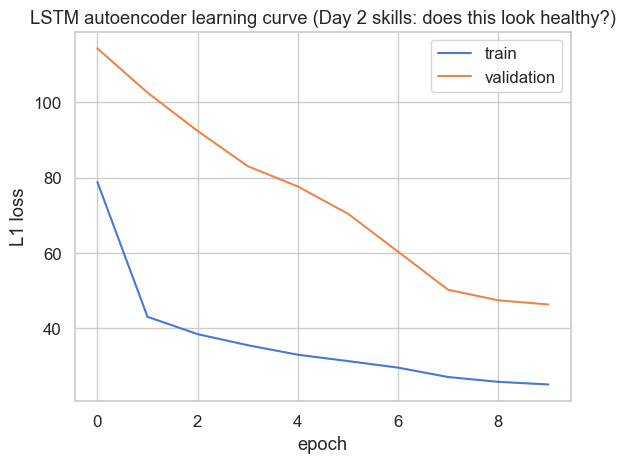

In [12]:
model, history = train_model(x_s_train_tensor, x_s_val_tensor, n_epochs=10, embedding_dim=8)

plt.plot(history['train'], label='train')
plt.plot(history['val'], label='validation')
plt.xlabel('epoch'); plt.ylabel('L1 loss'); plt.legend()
plt.title('LSTM autoencoder learning curve (Day 2 skills: does this look healthy?)')
plt.show()

In [ ]:
# Training loops can take hours on real data - always save your trained model (Day 1 lesson!)
MODEL_PATH = 'lstm_ae_capstone.pth'
torch.save(model.state_dict(), MODEL_PATH)

# ...and this is how you'd load it back later:
# model = MVLSTMAutoEncoder(seq_len=WINDOW, embedding_dim=8, feature_size=x_s_train_tensor.shape[-1])
# model.load_state_dict(torch.load(MODEL_PATH)); model = model.to(device).eval()

# May be better to save both the model and optimizer state_dicts, plus the epoch number, so you can resume training later.

## Step 5: From Reconstruction Error to a Threshold

The `predict` function returns the reconstruction loss for every sequence. The recipe:

1. Check the loss distribution on **training** data → what "normal" scores look like
2. Check it on **validation** data (normal, but unseen) → the *maximum* validation loss is a
   sensible starting point: "worse than anything we ever saw in normal operation"
3. Add a small **safety margin** on top (here: +5%). Deployment data is never *identical* to the data
   you calibrated on, so a threshold set exactly at the worst calibration error tends to trip on
   harmless normal variation. The margin trades a hair of sensitivity for far fewer false alarms.
4. Score the **test** data and compare against this threshold

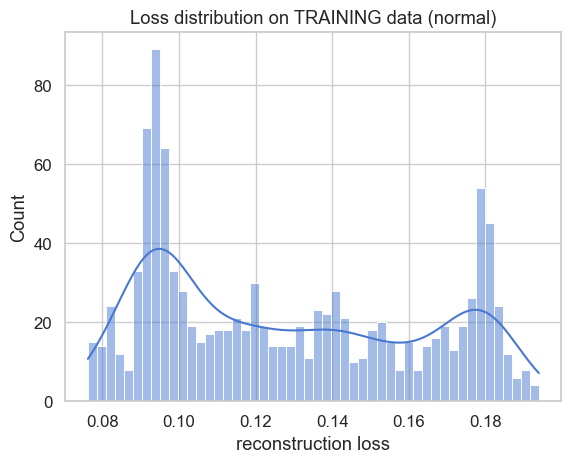

In [14]:
def predict(model, dataset):
    predictions, losses = [], []
    criterion = nn.L1Loss(reduction='mean').to(device)
    with torch.no_grad():   # only predicting - no learning here
        model = model.eval()
        for seq_true in dataset:
            seq_true = seq_true.to(device)
            seq_pred = model(seq_true)
            loss = criterion(seq_pred, seq_true)
            predictions.append(seq_pred.cpu().numpy().flatten())
            losses.append(loss.item())
    return predictions, losses

_, train_losses = predict(model, x_s_train_tensor)
sns.histplot(train_losses, bins=50, kde=True)
plt.xlabel('reconstruction loss'); plt.title('Loss distribution on TRAINING data (normal)')
plt.show()

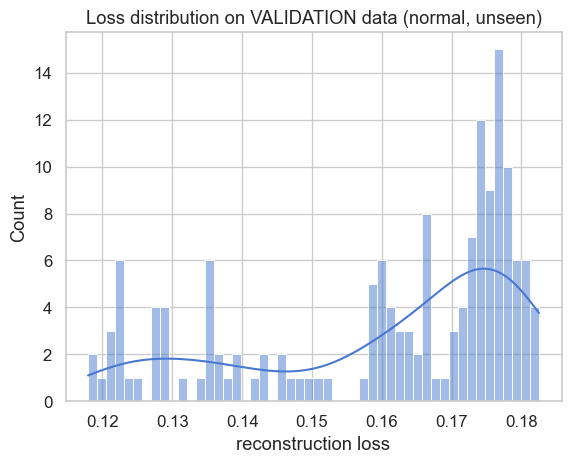

Threshold (max validation loss x1.05): 0.1916


In [15]:
_, val_losses = predict(model, x_s_val_tensor)
sns.histplot(val_losses, bins=50, kde=True)
plt.xlabel('reconstruction loss'); plt.title('Loss distribution on VALIDATION data (normal, unseen)')
plt.show()

SAFETY_MARGIN = 1.05      # +5% above the worst normal error we ever saw (calibration vs deployment gap)
THRESHOLD = np.max(val_losses) * SAFETY_MARGIN
print(f'Threshold (max validation loss x{SAFETY_MARGIN}): {THRESHOLD:.4f}')

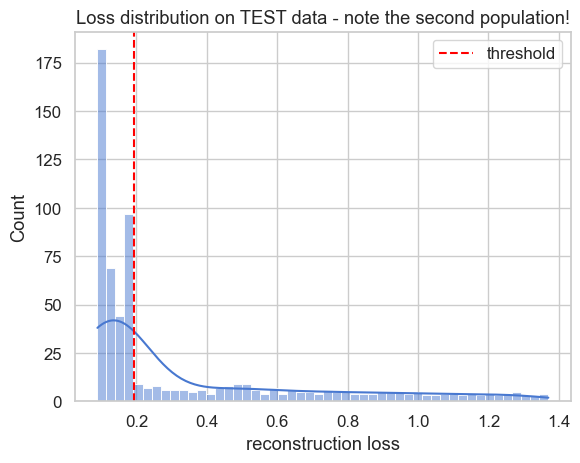

In [16]:
_, test_losses = predict(model, x_s_test_tensor)

sns.histplot(test_losses, bins=50, kde=True)
plt.axvline(THRESHOLD, color='red', linestyle='--', label='threshold')
plt.xlabel('reconstruction loss'); plt.legend()
plt.title('Loss distribution on TEST data - note the second population!')
plt.show()

If all went well, the test histogram is "two-headed": a big population of normal days below the
threshold, and a tail of badly-reconstructed sequences above it. Those are our anomalies — let's see
*when* they happen.

## Step 6: Detect, Visualise, Verify

In [17]:
# Build a score table aligned with the test timeline.
# Each sequence's loss is assigned to the timestamp of its LAST reading
# (a window can only be scored once it has fully happened).
score = pd.DataFrame(index=test_norm.index)
padded = np.append(np.repeat(np.nan, len(score.index) - len(test_losses)), test_losses)
score['Loss'] = padded
score['Threshold'] = THRESHOLD
score['Anomaly'] = score['Loss'] > score['Threshold']
score = score.dropna()

first_alarm = score[score['Anomaly']].index.min()
print(f'Ground-truth leak start : {leak_time}')
print(f'First alarm raised      : {first_alarm}')
print(f'Detection delay         : {first_alarm - leak_time}')
print(f'Sequences flagged       : {score["Anomaly"].sum()} / {len(score)}')

Ground-truth leak start : 2025-02-08 00:00:00
First alarm raised      : 2025-02-10 03:30:00
Detection delay         : 2 days 03:30:00
Sequences flagged       : 233 / 625


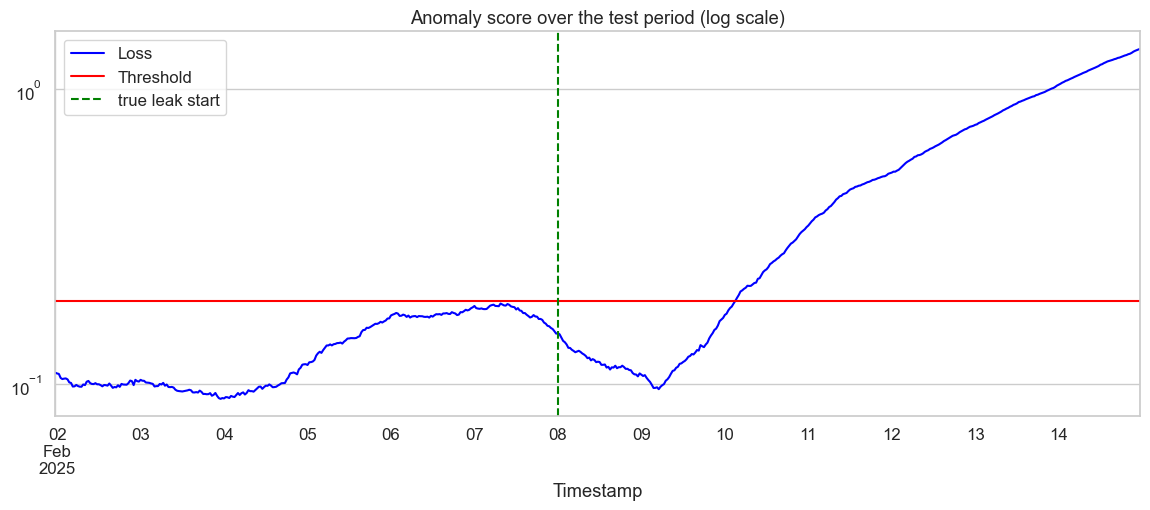

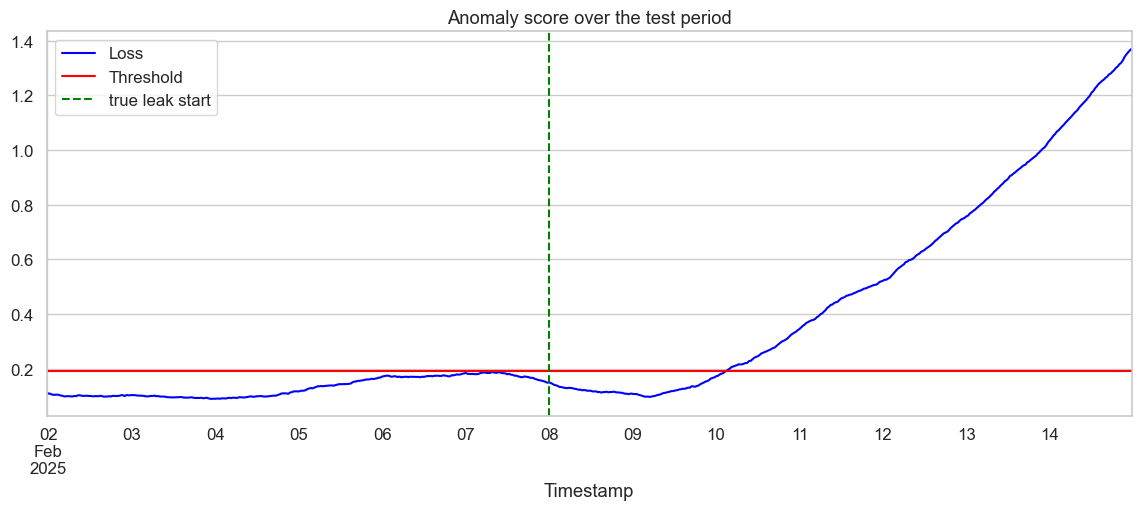

In [18]:
# Reconstruction error over time vs the threshold (log scale to see both regimes)
score[['Loss', 'Threshold']].plot(logy=True, figsize=(14, 5), color=['blue', 'red'])
plt.axvline(leak_time, color='green', linestyle='--', label='true leak start')
plt.legend(); plt.title('Anomaly score over the test period (log scale)')
plt.show()

# ...and on a linear scale
score[['Loss', 'Threshold']].plot(figsize=(14, 5), color=['blue', 'red'])
plt.axvline(leak_time, color='green', linestyle='--', label='true leak start')
plt.legend(); plt.title('Anomaly score over the test period')
plt.show()

In [19]:
# Save the results - on real projects, scoring a large test set can take a while,
# and your future self will thank you.
score.to_csv('capstone_anomaly_scores.csv')
score.tail()

,Loss,Threshold,Anomaly
Timestamp,,,
2025-02-14 21:30:00,1.340867,0.191646,True
2025-02-14 22:00:00,1.350029,0.191646,True
2025-02-14 22:30:00,1.357668,0.191646,True
2025-02-14 23:00:00,1.364896,0.191646,True
2025-02-14 23:30:00,1.370252,0.191646,True


The reconstruction error hugs the floor through the normal week, then climbs as the leak grows — and
the crossing point is our alarm. Note what the model was given: **zero examples of leaks**. It learned
what normal looks like, and the leak betrayed itself by being *not that*.

## Step 7 (Optional): Change Point Detection

The anomaly flags tell us *that* something is wrong; **change point detection** gives a principled
estimate of *when* the behaviour shifted. The [`ruptures`](https://centre-borelli.github.io/ruptures-docs/)
library's PELT algorithm finds the points where a signal's statistics change. 

Ideally, running it on our
reconstruction-error signal should land right on the leak onset.

The parameters that matter: `min_size` (minimum spacing between change points) and `pen`
(penalty — higher = fewer, more confident change points). The penalty must match the *scale* of your
signal, so we derive it from the signal's variance rather than hard-coding a number.

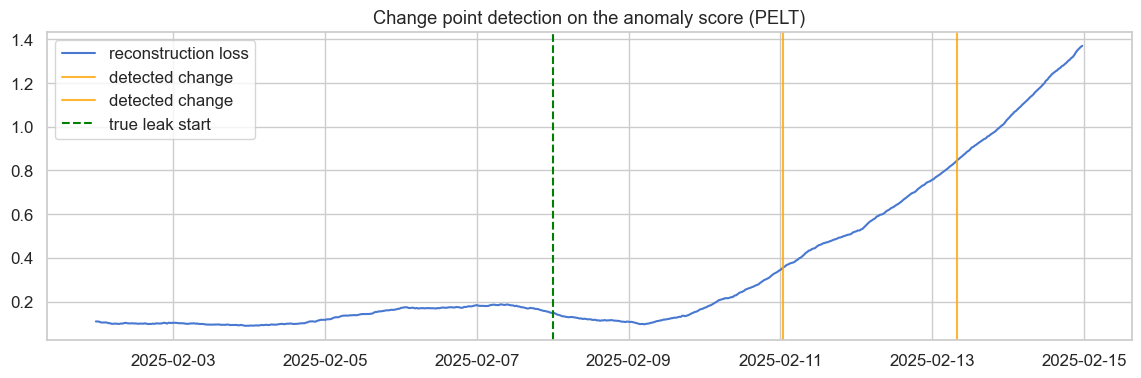

Detected change points: ['2025-02-11 01:00:00', '2025-02-13 08:00:00']


In [20]:
# OPTIONAL - requires:  pip install ruptures
import ruptures as rpt

signal = score['Loss'].values
algo = rpt.Pelt(model='l2', min_size=READINGS_PER_DAY).fit(signal)   # min 1 day between changes

# scale-aware penalty: proportional to signal variance (raise the 10 for fewer change points)
penalty = 10 * np.var(signal) * np.log(len(signal))
change_points = algo.predict(pen=penalty)

plt.figure(figsize=(14, 4))
plt.plot(score.index, signal, label='reconstruction loss')
for cp in change_points[:-1]:                       # last "change point" is just the series end
    plt.axvline(score.index[cp], color='orange', linestyle='-', alpha=0.8, label='detected change')
plt.axvline(leak_time, color='green', linestyle='--', label='true leak start')
plt.legend(); plt.title('Change point detection on the anomaly score (PELT)')
plt.show()

print('Detected change points:', [str(score.index[cp]) for cp in change_points[:-1]])

---

# Your Project: Make It Yours, Show It Off

You've just built an end-to-end anomaly detector on *simulated* data — now prove it on the **real
thing** and turn it into a portfolio piece. In `leak_db_sets/processed/` you have data from the
**Hanoi water-network benchmark (LeakDB)**: a *full year* of half-hourly pressure and flow readings
across the network (32 pressure nodes + 34 flow links, 2017).

<div style="text-align: center"><img src="hanoi.png" width="600"/></div>

| Scenario | Files | What's in it |
|---|---|---|
| **210** | `Scenario-210_pressures.csv`, `Scenario-210_flows.csv` | **Normal** operation — *no leaks*. Train on this. |
| **4** | `Scenario-4_pressures.csv`, `Scenario-4_flows.csv` | An **abrupt** leak (a sudden burst). |
| **212** | `Scenario-212_pressures.csv`, `Scenario-212_flows.csv` | An **incipient** leak (one that grows *slowly*). |

Your mission: train the autoencoder on the normal year (**Scenario 210**), then detect the leaks in
**Scenarios 4 and 212**. The pipeline is exactly the one you just built — and
`extras/LSTM_AE_Hanoi_reference.ipynb` is a complete worked template for this very dataset.

> **Normalisation, revisited.** This is a *year* of data with real seasonal demand (water use climbs in
> summer). That's precisely the case where a **moving** z-score earns its keep — its rolling baseline
> follows the slow season but a leak still stands out — unlike our short simulated capstone, where a
> *static* z-score was better. *Match the tool to the data.*

<div style="text-align: center"><img src="hanoi_trend.png" width="900"/></div>

### Core tasks

1. **Abrupt vs incipient.** Run your detector on both Scenario 4 (abrupt) and Scenario 212 (incipient).
   Which is easier to catch, and why? (Remember how a *slowly* changing signal can hide from a
   detector.) Report the detection delay for each — the ground-truth leak times are in each scenario's
   `Labels.csv` and `Leak_n_info.csv` under `leak_db_sets/unprocessed/`.
2. **Better evaluation** Track "false alarms", "Time-to-detection" and even "leak state" to see how the models compare when using various evaluation metrics.
3. **Tune it (Day 2 skills).** Vary `embedding_dim` (2 / 8 / 32), the window length, and training
   epochs. Read the learning curves. Which configuration detects fastest with the fewest false alarms?
4. **Minimum Train Size** Vary the train size (One week, 1 month etc). How much historical data does your model need before it can detect leaks reliably?

### Extensions (pick at least one)

- **Localise the leak.** Compute reconstruction error *per sensor* (don't average over features).
  Which pressure nodes / flow links scream loudest? Do they line up with where the leak actually is?
- **Architecture swap.** Build a Conv1D autoencoder, or the Conv+LSTM hybrid from
  `extras/conv_lstm_output_dimensions_test.ipynb`, and benchmark it against the LSTM-AE.
- **Another domain.** Take your pipeline somewhere completely different — the NAB benchmark (NYC taxi
  demand) or ECG5000 heartbeats — to prove the approach generalises beyond water networks.
- **Ship it.** Wrap the trained model in a function `is_anomalous(last_24h) -> bool` and simulate
  streaming detection by feeding the test set one reading at a time.

### Show-off checklist (presentations)

- One slide: the problem and why labels don't exist for it
- One plot: your **learning curves** (prove the model trained healthily)
- One plot: **loss distributions** with your threshold (prove the separation is real)
- One plot: the **timeline** — anomaly score, threshold, true leak, first alarm
- One number: your **detection delay**, and one honest sentence about false alarms
- Push the notebook to GitHub with a README. *That's a portfolio project.*

---

# The Week in One Picture

| Day | You learned | The capstone used it |
|---|---|---|
| 1 | Neurons, layers, losses, training loops, PyTorch | Every line of the model & training code |
| 2 | Learning curves, validation, thresholds, tuning, debugging | Healthy training + threshold calibration |
| 3 | Spatial feature extraction, CNNs, reusable train functions | The Conv-AE extension; the training pattern |
| 4 | Sequences, LSTMs, windowing, encoder–decoder | The heart of the autoencoder |
| 5 | Unsupervised learning, autoencoders, anomaly detection | The whole pipeline |

Five days ago, "teach a computer to think" was a question. Today you trained a network that noticed
something going wrong *that nobody ever showed it*. Where you take that next — speech, vision,
medicine, infrastructure — is up to you.

**Congratulations — you made it. Now go show it off.** 🎓